# 5. Which of the week's steps belong in the workbook, which must never be done there, and how do the two stay in step?

**Week 2, Friday. Chapter 5 of 6.** Chapters 1 to 4 built the chief of staff's three deliverables: the
tree by segment for both quarters, tied to the warehouse's Rs 10.00 crore and Rs 9.84 crore; the protect
list of fifty with a lookup that says when an id is missing; and the front-page card with its period,
comparison and base, which reads down 1.6 percent and prints Retail-Plus's 29.4 percent fall as
Rs 1.72 lakh, 0.4 percent of revenue. Kavya's challenge is the rule behind them.

Three tools did the week's work. The warehouse is the Postgres database that holds one row per order
and one per payment, the source of truth anyone can query and rerun. pandas is the Python library for
tables, where an analyst tries an idea, checks it and tries again before anyone relies on the result;
that trying is what this chapter calls the analyst's iteration. The workbook is the Excel file a
director opens. A dedupe is any step that makes each order or payment count once.

> **Kavya asks.** "Everything you built this week has to survive a room that only has Excel. Which parts
> belong in Excel, which parts must never be in Excel, and how do you keep the two from drifting apart?"
>
> Kavya Nair, senior analyst, Kalpa Retail data team

**Who needs the answer.** Kavya signs the team's operating rule; Anand Iyer, the finance controller,
has an analyst who audits every number Finance relies on; the data platform lead owns the warehouse. A
step done in the wrong tool ships a number nobody can rerun, and a join done in a sheet can report as
unpaid money that customers have paid.

**The questions on the way.**
1. Where could the week's work live?
2. What did each day of the week build, and what does each step touch?
3. What does booked against collected say when a lookup does the join?
4. Why is it wrong, and what does adding every payment say?
5. Where does each of the week's steps belong?
6. How do the workbook and the warehouse stay in step?

**The metric at stake.** Collected against booked, Tuesday's report for Anand: booked is the value of
the orders, collected is the money received against them. It is the test case for the rule, because it
needs a join, one order to several payments.

**Who else faces it.** In October 2020 Public Health England reported that "15,841 cases between 25
September and 2 October were not included in the reported daily COVID-19 cases" (GOV.UK, PHE statement
on delayed reporting of COVID-19 cases, 4 October 2020, checked 30 September 2026). The BBC explained
that the files passed through templates in the old XLS format, so "each template could handle only
about 65,000 rows of data rather than the one million-plus rows that Excel is actually capable of" (BBC
News, 5 October 2020, checked 30 September 2026). A step of a data pipeline was running in a
spreadsheet.

**Setup.** The cell loads the raw export, one row per payment with the order's amount repeated on each,
counts each order once the way chapter 2 did, and defines `warehouse()`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv
import pandas as pd

DATA = kit.data_dir()
SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]


def crore(n):
    return f"Rs {n / 1e7:.2f} crore"


def lakh(n):
    return f"Rs {n / 1e5:.2f} lakh"


def money(n):
    """Rupees the way Kalpa's finance team reads them: crore, lakh, or rupees in full."""
    sign, a = ("-" if n < 0 else ""), abs(n)
    return sign + (crore(a) if a >= 1e7 else lakh(a) if a >= 1e5 else kit.rupees(round(a)))


def change(before, after):
    """The change from before to after, measured on before, in percent."""
    return (after - before) / before * 100

raw = pd.read_csv(DATA / "C2_W02_D05_raw_export_STUDENT.csv", keep_default_na=False)
raw["quarter"] = raw["order_date"].str[5:7].astype(int).map(lambda m: "Q1" if m <= 6 else "Q2")


def warehouse(query):
    """Ask the Kalpa warehouse itself, the source of truth every sheet ties back to."""
    return [{k: (int(v) if hasattr(v, "as_integer_ratio") and not isinstance(v, float) else v)
             for k, v in row.items()} for row in kit.sql(query)]

raw["first_row"] = (raw.groupby("order_id").cumcount() == 0).astype(int)   # =IF(COUNTIF($A$2:A2,A2)=1,1,0)
orders = raw[raw["first_row"] == 1]                                      # one row per order

print(f"{len(raw):,} payment rows, {len(orders):,} orders")

1,450 payment rows, 1,000 orders


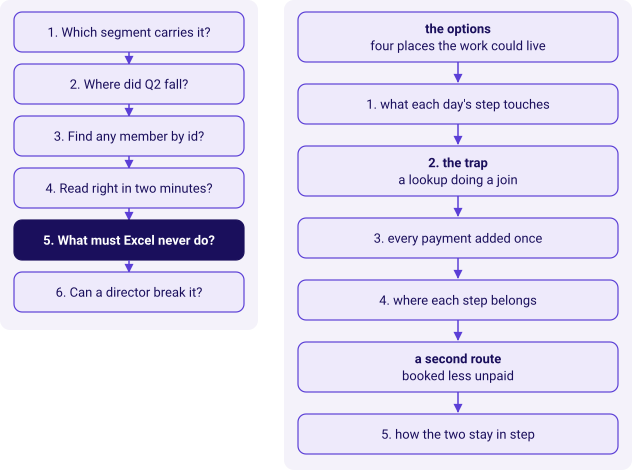

In [2]:
kit.side_by_side(
    kit.ladder(['Which segment carries it?', 'Where did Q2 fall?', 'Find any member by id?', 'Read right in two minutes?', 'What must Excel never do?', 'Can a director break it?'], lit=4, show=False),
    kit.vflow(['the options\nfour places the work could live', "1. what each day's step touches", '2. the trap\na lookup doing a join', '3. every payment added once', '4. where each step belongs', 'a second route\nbooked less unpaid', '5. how the two stay in step'], show=False),
)

## Where could the week's work live, and what does each arrangement cost?

| Option | Who does what | What it assumes |
|---|---|---|
| a) Everything in the workbook | Joins, dedupes, ranks and the card, all as formulas over the exports | The author reruns every step by hand each Monday |
| b) The split | The warehouse computes and cleans; pandas iterates; the workbook presents | Each tool does only what it is best at, and the three are tied on every refresh |
| c) pandas does it all and pastes values | A notebook writes the numbers into the workbook as values | Nobody changes an assumption in the room |
| d) A dashboard on the warehouse | Every number live from the warehouse | Every director has a login, which the brief rules out |

option,collected per order costs,who can rerun it,what an auditor can trace
a) all in the workbook,"1,000 SUMIFS x 1,450 rows = 1,450,000 tests a recalculation","its author, by hand",none beyond the cells
b) the split,"one GROUP BY over 1,428 payments",anyone with the query,"the query, in version control"
c) pandas pastes values,"one groupby over 1,450 rows","the analyst, with the notebook",the notebook
d) dashboard,a query a view,the dashboard's owner,the queries


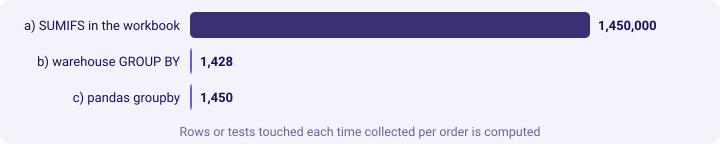

In [3]:
payments = warehouse("SELECT count(*) AS n FROM payments")[0]["n"]
sizing = [
    ("a) all in the workbook", f"{len(orders):,} SUMIFS x {len(raw):,} rows = {len(orders) * len(raw):,} tests a recalculation", "its author, by hand", "none beyond the cells"),
    ("b) the split", f"one GROUP BY over {payments:,} payments", "anyone with the query", "the query, in version control"),
    ("c) pandas pastes values", f"one groupby over {len(raw):,} rows", "the analyst, with the notebook", "the notebook"),
    ("d) dashboard", "a query a view", "the dashboard's owner", "the queries"),
]
kit.table(["option", "collected per order costs", "who can rerun it", "what an auditor can trace"], sizing,
          caption="The four arrangements, sized on one step: collected per order")
kit.bars([("a) SUMIFS in the workbook", len(orders) * len(raw)), ("b) warehouse GROUP BY", payments),
          ("c) pandas groupby", len(raw))], lit=(0,),
         title="Rows or tests touched each time collected per order is computed")

**The best-fit call: b, the split.** The warehouse owns every join, dedupe and rank, because a query
can be rerun and audited; pandas owns the analyst's iteration; the workbook owns what a director
sees and changes in the meeting. **The fact
that would change it:** a one-off question nobody audits and nobody reruns can live in a sheet, and a
question Finance will rely on every week cannot.

## 1. What did each day of the week build, and what does each step touch?

**Predict before you run.** Which of the week's steps touches the most rows? a) the tree by segment and
quarter; b) booked against collected; c) the top fifty per segment; d) Friday's pivot.

Day,Step,Tables it reads,How
Monday,the tree by segment and quarter,orders,a GROUP BY
Tuesday,booked against collected,orders and payments,"a join, one order to several payments"
Wednesday,"the top fifty per segment, falling spend",orders,"window functions: a rank or a running total over rows, in SQL"
Thursday,the customer table,"orders, customers, campaign exposure","a merge in pandas, checked to stay one row per customer"
Friday,"the pivot, the lookup, the card",the two exports,presentation in the workbook


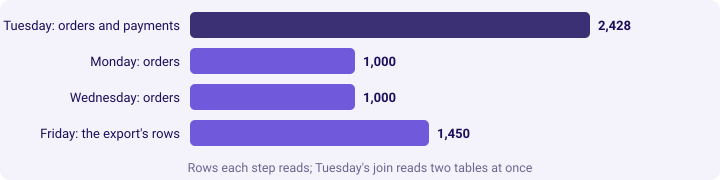

In [4]:
steps = [
    ("Monday", "the tree by segment and quarter", "orders", "a GROUP BY"),
    ("Tuesday", "booked against collected", "orders and payments", "a join, one order to several payments"),
    ("Wednesday", "the top fifty per segment, falling spend", "orders", "window functions: a rank or a running total over rows, in SQL"),
    ("Thursday", "the customer table", "orders, customers, campaign exposure", "a merge in pandas, checked to stay one row per customer"),
    ("Friday", "the pivot, the lookup, the card", "the two exports", "presentation in the workbook"),
]
counts = {"orders": warehouse("SELECT count(*) AS n FROM orders")[0]["n"], "payments": payments}
kit.table(["Day", "Step", "Tables it reads", "How"], steps, caption="The week's steps and what each reads")
kit.bars([("Tuesday: orders and payments", counts["orders"] + counts["payments"]), ("Monday: orders", counts["orders"]),
          ("Wednesday: orders", counts["orders"]), ("Friday: the export's rows", len(raw))], lit=(0,),
         title="Rows each step reads; Tuesday's join reads two tables at once")
kit.check("Tuesday's join reads more rows than any single table", counts["orders"] + counts["payments"] > len(raw))

**What happened.** The answer is b. Tuesday's report joins 1,000 orders to 1,428 payment rows, eight of
which match no order, and it is
the one step where one row on one side meets several on the other. That is the step to watch when
somebody offers to "just do it in the sheet".

## 2. What does booked against collected say when a lookup does the join?

Anand asks whether the deck pack could carry Tuesday's collected figure as well, computed in the
workbook so nobody needs a login. A hurried analyst fills a lookup beside each order in the raw export:
`=VLOOKUP(A2, RawExport!A:H, 7, FALSE)`, the exact match on the order id that fetches `paid_amount`.

**Predict before you run.** Collected, added up over the 1,000 orders, reads about: a) Rs 19.7 crore; b)
Rs 11.8 crore; c) Rs 39 crore; d) exactly booked.

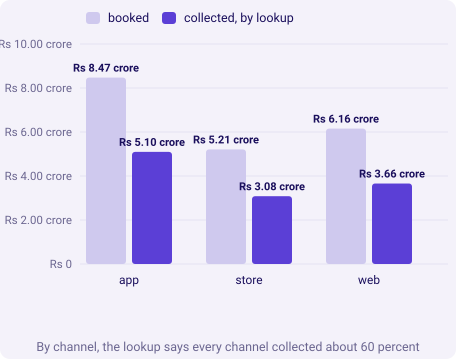

In [5]:
first_paid = raw.drop_duplicates("order_id").set_index("order_id")["paid_amount"]    # what a lookup returns
booked = int(orders["order_amount"].sum())
looked_up = int(first_paid.sum())
kit.stats([(money(booked), "booked", "the orders' value"),
           (money(looked_up), "collected, by lookup", "one payment per order"),
           (money(booked - looked_up), "outstanding, it says", f"{(booked - looked_up) / booked * 100:.1f} percent of booked")])
by_channel = orders.groupby("channel")["order_amount"].sum()
lk_channel = raw.drop_duplicates("order_id").groupby("channel")["paid_amount"].sum()
kit.columns(["app", "store", "web"], [("booked", [int(by_channel[c]) for c in ["app", "store", "web"]]),
                                      ("collected, by lookup", [int(lk_channel[c]) for c in ["app", "store", "web"]])],
            fmt=money, title="By channel, the lookup says every channel collected about 60 percent")

**What happened: the plausible wrong answer.** The answer is b. The lookup says Rs 11,83,81,974
collected against Rs 19,84,00,000 booked, Rs 8.00 crore outstanding, 40.3 percent. Every formula is an
exact match and every row looks right. On that figure Anand's collections team
chases Rs 8 crore from accounts that have paid, most of them corporate buyers, and the board pack
reports a cash problem Kalpa does not have.

## 3. Why is it wrong, and what does adding every payment say?

**Why it is wrong.** A lookup returns the first row that matches and stops. The export has one row per
payment, and 450 orders sit on two rows: 400 paid in two instalments, whose second payment the lookup
never reads, and 50 that the gateway posted twice, whose two rows are the same payment. **The check
that catches it:** count the rows each order has, and read any order with two rows before trusting its
first. **The fix:** add every payment once. In the sheet that is `=SUMIFS(G:G, A:A, A2)` over the rows
left once the gateway's exact copies are gone; in the warehouse it is Tuesday's join, one row per
payment.

**Predict before you run.** With every payment added once, collected is short of booked by about: a)
Rs 8.00 crore; b) Rs 17.5 lakh; c) nothing; d) Rs 39 crore.

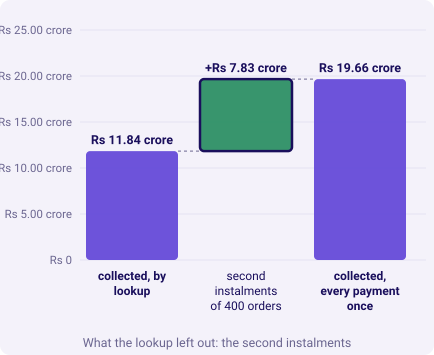

In [6]:
paid_rows = raw.drop(columns=["quarter", "first_row"]).drop_duplicates()   # a gateway copy is one payment, posted twice
collected = int(paid_rows["paid_amount"].sum())                             # =SUMIFS(G:G, A:A, A2), every payment once
copies = len(raw) - len(paid_rows)
second_inst = collected - looked_up
kit.bridge(("collected, by lookup", looked_up), [("second instalments of 400 orders", second_inst)],
           end_label="collected, every payment once", fmt=money, lit=(0,),
           title="What the lookup left out: the second instalments")
kit.stats([(money(collected), "collected, every payment once", "the warehouse's join, or SUMIFS on the payments"),
           (money(booked - collected), "short of booked", f"{(booked - collected) / booked * 100:.1f} percent"),
           (f"{copies}", "gateway copies set aside", "the same payment, posted twice")])
kit.check("the lookup and the sum differ on exactly the orders with two rows",
          int((raw.groupby("order_id").size() > 1).sum()) == 450)
kit.check("every payment added once leaves collected within 1 percent of booked", (booked - collected) / booked < 0.01)

**What happened.** The answer is b. Every payment added once gives Rs 19,66,45,070 collected,
Rs 17,54,930 short of booked, 0.9 percent, which is exactly Tuesday's list of orders nobody has paid
for. **What changed:** Rs 7,82,63,096 of "outstanding" money disappears, the second instalments of 400
orders, and the 50 gateway copies count once, as the payments they are. The join belongs where Tuesday
did it, in the warehouse, and a SUMIFS in the sheet is only a check against it.

## 4. Where does each of the week's steps belong?

**Predict before you run.** Counting each order once in the raw export belongs: a) in the workbook, as
the first-row flag; b) in the warehouse, as an export at the order grain; c) in pandas, as a
drop_duplicates; d) anywhere, since all three give Rs 19.84 crore.

Step,Where it lives,Why
the tree by segment and quarter,warehouse,Finance audits it; a GROUP BY anyone can rerun
counting each order once,warehouse,a grain fix is cleaning; the export should arrive at the order grain
booked against collected,warehouse,"a join, one order to several payments"
"the top fifty, with a rule for members tied at fifty",warehouse,a rank Finance and Marketing both rely on
the customer table,pandas,"the analyst's weekly iteration, until Finance relies on it"
"the pivot, the lookup, the card",workbook,presentation on an export that ties
a director's what-if,workbook,"a labelled input beside the actual, never over it"


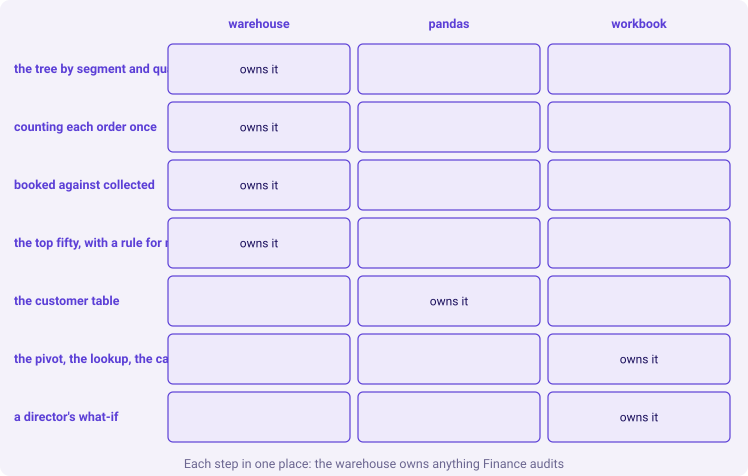

In [7]:
rule = [
    ("the tree by segment and quarter", "warehouse", "Finance audits it; a GROUP BY anyone can rerun"),
    ("counting each order once", "warehouse", "a grain fix is cleaning; the export should arrive at the order grain"),
    ("booked against collected", "warehouse", "a join, one order to several payments"),
    ("the top fifty, with a rule for members tied at fifty", "warehouse", "a rank Finance and Marketing both rely on"),
    ("the customer table", "pandas", "the analyst's weekly iteration, until Finance relies on it"),
    ("the pivot, the lookup, the card", "workbook", "presentation on an export that ties"),
    ("a director's what-if", "workbook", "a labelled input beside the actual, never over it"),
]
kit.table(["Step", "Where it lives", "Why"], rule, caption="The week's steps, placed")
tools = ["warehouse", "pandas", "workbook"]
kit.matrix([r[0] for r in rule], tools, [["owns it" if r[1] == t else "" for t in tools] for r in rule],
           title="Each step in one place: the warehouse owns anything Finance audits")
kit.check("every step lives in exactly one place", all(sum(r[1] == t for t in tools) == 1 for r in rule))

**What happened.** The answer is b. The first-row flag in chapter 2 was the right move for Friday's
deadline, and it is a cleaning step with no record; next week the export should arrive at the order
grain from the warehouse, and the flag becomes a check. Written as the team's rule, in three lines: the warehouse owns
the number and every join, dedupe and rank Finance relies on; pandas owns the analyst's iteration until
Finance relies on it; the workbook owns the last mile, presenting, slicing, looking up and taking
what-ifs as labelled inputs, on an export that ties, and nobody types over the source.

## A second route: does booked less the orders nobody paid for give the same collected figure?

A second route has to be able to disagree, so it never adds a payment. It starts from the warehouse's
booked revenue and takes away the orders that have no payment at all, Tuesday's unpaid list, found
with an anti-join: every order with no matching row in the payments table.

Figure,"The export, every payment once","The warehouse, booked less unpaid"
booked,"Rs 19,84,00,000","Rs 19,84,00,000"
unpaid orders,,"30 orders, Rs 17,54,930"
collected,"Rs 19,66,45,070","Rs 19,66,45,070"


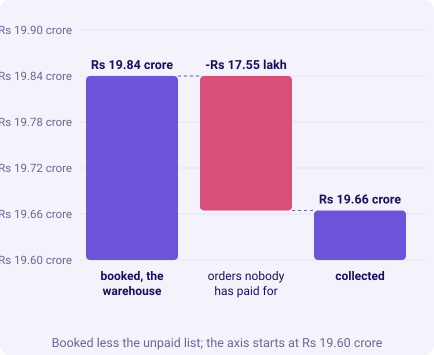

In [8]:
wb = warehouse("SELECT sum(amount) AS booked FROM orders")[0]["booked"]
unpaid = warehouse("SELECT count(*) AS n, sum(amount) AS amount FROM orders o "
                   "WHERE NOT EXISTS (SELECT 1 FROM payments p WHERE p.order_id = o.order_id)")[0]
kit.table(["Figure", "The export, every payment once", "The warehouse, booked less unpaid"],
          [("booked", kit.rupees(booked), kit.rupees(wb)),
           ("unpaid orders", "", f"{unpaid['n']} orders, {kit.rupees(unpaid['amount'])}"),
           ("collected", kit.rupees(collected), kit.rupees(wb - unpaid["amount"]))])
kit.bridge(("booked, the warehouse", wb), [("orders nobody has paid for", -unpaid["amount"])],
           end_label="collected", fmt=money, lo=196_000_000,
           title="Booked less the unpaid list; the axis starts at Rs 19.60 crore")
kit.check("collected ties to booked less the unpaid list, to the rupee", collected == wb - unpaid["amount"])
kit.check("booked ties too", booked == wb)

## 5. How do the workbook and the warehouse stay in step?

With a drift check that runs on every refresh. The workbook needs no login for it: the data platform
lead sends the warehouse's control totals, orders and booked revenue per quarter, on a small tab
beside each export, and the Checks tab compares the workbook's own totals with them, live. A mismatch
holds the deck until someone knows why. The cell below
runs it twice: on this export, and on the same export as it would have looked if it had been pulled a
week early, before the last week of September's orders arrived.

**Predict before you run.** The check on the early export: a) passes, since every row in it is real; b)
holds the deck, since Q2 falls short of the warehouse; c) holds only the protect list; d) cannot run.

Export,Quarter,Orders in it,Warehouse orders,Revenue in it,Warehouse revenue,Verdict
today,Q1,538,538,"Rs 10,00,00,000","Rs 10,00,00,000",ship
today,Q2,462,462,"Rs 9,84,00,000","Rs 9,84,00,000",ship
a week early,Q1,538,538,"Rs 10,00,00,000","Rs 10,00,00,000",hold
a week early,Q2,430,462,"Rs 9,20,15,460","Rs 9,84,00,000",hold


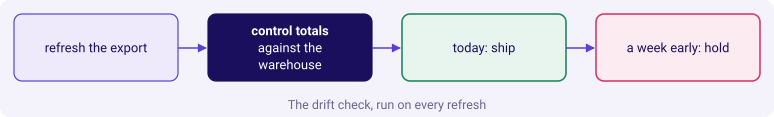

In [9]:
def drift(export_orders):
    """The workbook's quarters against the warehouse's, as the Checks tab would compare them."""
    wq = {r["quarter"]: r for r in warehouse("SELECT quarter, count(*) AS n, sum(amount) AS revenue FROM orders GROUP BY quarter")}
    rows = []
    for q in ["Q1", "Q2"]:
        mine = export_orders[export_orders["quarter"] == q]
        rows.append((q, len(mine), wq[q]["n"], int(mine["order_amount"].sum()), wq[q]["revenue"]))
    ok = all(r[1] == r[2] and r[3] == r[4] for r in rows)
    return rows, ("ship" if ok else "hold")


today, verdict_today = drift(orders)
early = orders[orders["order_date"] < "2026-09-22"]
week_early, verdict_early = drift(early)
kit.table(["Export", "Quarter", "Orders in it", "Warehouse orders", "Revenue in it", "Warehouse revenue", "Verdict"],
          [("today", *r[:3], kit.rupees(r[3]), kit.rupees(r[4]), verdict_today) for r in today]
          + [("a week early", *r[:3], kit.rupees(r[3]), kit.rupees(r[4]), verdict_early) for r in week_early])
kit.flow(["refresh the export", "control totals\nagainst the warehouse", f"today: {verdict_today}", f"a week early: {verdict_early}"],
         kinds=["plain", "lit", "good", "bad"], title="The drift check, run on every refresh")
kit.check("today's export ties, so the deck ships", verdict_today == "ship")
kit.check("the early export is caught", verdict_early == "hold")

**What happened.** The answer is b. Every row in the early export is real, and Q2 still falls short of
the warehouse, so the check holds the deck until someone pulls a fresh export. The same check catches a
number typed over in the workbook, since the workbook's totals would no longer match; chapter 6 hands the
workbook to a director and builds the tab that runs it.

> **Kavya's review.** "Excel presents; it does not clean, join or compute the source of truth, because a
> sheet with a typed-over cell has no audit trail. The warehouse owns the numbers, pandas owns your
> iteration, Excel owns the last mile, and the drift check holds the deck whenever the workbook stops
> tying to the warehouse."

### In the interview: SQL, pandas or Excel, and why can a lookup not stand in for a join?

**[S] SQL, pandas or Excel: how do you choose?** By who has to trust the number and who has to rerun
it. Anything Finance relies on, and every join, dedupe or rank behind it, is SQL in the warehouse,
rerun by anyone with the query. The analyst's iteration is pandas until Finance relies on it, so
Thursday's customer table could be built in pandas and moves upstream once Marketing depends on it
every Monday. The room's last mile is Excel on an export that ties, where a director can slice and
ask what-ifs.

**[F] A lookup does a join in a sheet and collected falls by 40 percent. What happened?** The lookup
returned the first payment of each order and ignored the rest. Here 450 orders had two payment rows, so
collected read Rs 11.84 crore against Rs 19.84 crore booked; adding every payment once gives Rs 19.66
crore, 0.9 percent short, which is exactly the orders nobody has paid for. One-to-many relations are
joined in the warehouse, and a SUMIFS in the sheet is only a check.

**[D] Kavya asks for the operating rule in three lines. Say it.** The warehouse owns the number and every
join, dedupe and rank Finance relies on. pandas owns the analyst's iteration until Finance relies on it.
Excel owns the last mile, on an export that ties, with what-ifs as labelled inputs, and a drift check on
every refresh ties the sheet back to the warehouse.

### Depth: why did a row limit lose cases instead of stopping the job?

The BBC's account of the Public Health England loss says each XLS template "could handle only about
65,000 rows", and that "since each test result created several rows of data, in practice it meant that
each template was limited to about 1,400 cases" (BBC News, 5 October 2020, checked 30 September 2026).
Microsoft's documentation gives the old format's limit exactly: "Excel 2003 supports a maximum of 65,536
rows per worksheet" (Microsoft Learn, Work around the Excel 2003 row limitation, checked 30 September
2026). Rows past the limit were dropped with no error, and a lookup that takes one payment of two
fails the same way: nothing turns red, and the total comes out smaller than the truth. A drift check
against an upstream count is what turns a silent loss into a held release.

## Where does each of the week's steps live, and how do the two stay in step, question by question?

1. Option b, the split: the warehouse computes and cleans, pandas iterates, the workbook presents.
2. Tuesday's booked against collected is the heaviest step, a join of 1,000 orders to 1,428 payment rows, eight of which match no order; the rest read one table.
3. A lookup doing the join says Rs 11,83,81,974 collected, "Rs 8.00 crore outstanding", 40.3 percent.
4. It took the first payment of 450 two-row orders; every payment added once gives Rs 19,66,45,070, Rs 17,54,930 short, 0.9 percent, exactly the orders nobody has paid for.
5. Joins, dedupes, ranks and anything Finance audits live in the warehouse; the customer table in pandas; the pivot, lookup, card and what-ifs in the workbook.
6. A drift check on every refresh ties the workbook's quarters to the warehouse: today's export ships, a week-early export is held.

The next question is chapter 6's: what happens when a director takes the workbook in the room.

In [10]:
kit.check_summary()